# Análisis Exploratorio

**Autores:** Sergio Rada, Carlos Romero, Camilo Mujica y Natalia Alvarado.  

## Contexto inicial  

Las enfermedades cardiovasculares son la principal causa de muerte en todo el mundo, según la OMS. Detectarlas a tiempo es fundamental para evitar complicaciones graves. Con la digitalización de los historiales médicos y la disponibilidad de datos clínicos estructurados, ahora es posible utilizar técnicas de aprendizaje automático para predecir el riesgo de falla cardíaca.

El dataset “Heart Failure Prediction” contiene registros clínicos de pacientes, con variables como presión sanguínea, colesterol, glucosa, edad, entre otras. El objetivo es construir un modelo de clasificación binaria que prediga si un paciente está en riesgo de sufrir una falla cardíaca o no (HeartDisease = 1 o 0).

Este proyecto guía el desarrollo de un flujo completo de Machine Learning Operations (MLOps) de manera local, con herramientas modernas como FastAPI, Docker, Kubernetes, CI/CD con GitHub Actions y monitoreo con Evidently.   

- fuente: Kaggle https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction 

## Carga del Dataset  

In [1]:
# Carga de librerias  
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns
import math

#Carga de datos  
df = pd.read_csv("heart.csv")

In [2]:
#Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [3]:
#Dimensiones del dataset
df.shape

(918, 12)

Se cuenta con una cantidad total de 918 observaciones, cada una representando un paciente, caracterizado por 12 variables. A continuación se presenta la descripción de cada variable:  

- Age: edad del paciente [años].
- Sex: sexo del paciente [M: Masculino, F: Femenino].
- ChestPainType: tipo de dolor de pecho [TA: Angina típica, ATA: Angina atípica, NAP: Dolor no anginoso, ASY: Asintomático].
- RestingBP: presión arterial en reposo [mm Hg].
- Cholesterol: colesterol sérico [mm/dl].
- FastingBS: azúcar en sangre en ayunas [1: si Glucemia en ayunas > 120 mg/dl, 0: en caso contrario].
- RestingECG: resultados del electrocardiograma en reposo [Normal: Normal, ST: presenta anomalía de la onda ST-T (inversiones de la onda T y/o elevación o - depresión del segmento ST de > 0,05 mV), HVI: muestra hipertrofia ventricular izquierda probable o definitiva según los criterios de Estes].
- MaxHR: frecuencia cardíaca máxima alcanzada [Valor numérico entre 60 y 202].
- ExerciseAngina: angina inducida por el ejercicio [S: Sí, N: No].
- Oldpeak: oldpeak = ST [Valor numérico medido en la depresión].
- ST_Slope: la pendiente del segmento ST de ejercicio máximo [Arriba: ascendente, Plano: plano, Abajo: descendente].
- HeartDisease : clase de salida [1: enfermedad cardíaca, 0: normal].  

Ahora se visualizarán las 10 primeras entradas del dataset.   

In [4]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


Véase ahora el número de variables categóricas y numéricas.  

In [5]:
#Variables numéricas
num_vars = df.select_dtypes(include=['int64', 'float64'])

#Variables categóricas
cat_vars = df.select_dtypes(include=['object', 'category'])

print("Número de variables numéricas:", num_vars.shape[1])
print("Número de variables categóricas:", cat_vars.shape[1])

Número de variables numéricas: 7
Número de variables categóricas: 5


Seguido a esto se visualizarán los datos faltantes que tienen las variables para mirar la posibilidad de hacer su debido tratamiento.  

In [6]:
#Valores Faltantes
missing = df.isna().sum().to_frame("NaN")
missing["Porcentaje"] = (missing["NaN"] / len(df)) * 100
missing

,NaN,Porcentaje
Age,0,0.0
Sex,0,0.0
ChestPainType,0,0.0
RestingBP,0,0.0
Cholesterol,0,0.0
FastingBS,0,0.0
RestingECG,0,0.0
MaxHR,0,0.0
ExerciseAngina,0,0.0
Oldpeak,0,0.0


Nótese que no existen valores nulos en el dataset.  

## Análisis univariado  

A continuación se procederá a examinar cada variable de forma individual con el objetivo de entender su distribución, medidas centrales y de dispersión. Para complementar el análisis utilizaremos tablas estadísticas y gráficas según se considere adecuado.   

### Variables Categóricas  

Para esta sección se presentarán las tablas de frecuencia de cada variable categórica sin descripción.  

#### Sex  

In [13]:
tabla = (
    df['Sex']
    .value_counts()
    .rename_axis('Sex')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,Sex,conteo,Porcentaje
0,M,725,79.0
1,F,193,21.0


#### ChestPainType   

In [18]:
tabla = (
    df['ChestPainType']
    .value_counts()
    .rename_axis('ChestPainType')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)

tabla

,ChestPainType,conteo,Porcentaje
0,ASY,496,54.0
1,NAP,203,22.1
2,ATA,173,18.8
3,TA,46,5.0


#### RestingECG  

In [20]:

tabla = (
    df['RestingECG']
    .value_counts()
    .rename_axis('RestingECG')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,RestingECG,conteo,Porcentaje
0,Normal,552,60.1
1,LVH,188,20.5
2,ST,178,19.4


#### ExerciseAngina  

In [ ]:
tabla = (
    df['ExerciseAngina']
    .value_counts()
    .rename_axis('ExerciseAngina')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,ExerciseAngina,conteo,Porcentaje
0,N,547,59.6
1,Y,371,40.4


#### ST_Slope 

In [25]:
tabla = (
    df['ST_Slope']
    .value_counts()
    .rename_axis('ExerciseAngina')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla



,ExerciseAngina,conteo,Porcentaje
0,Flat,460,50.1
1,Up,395,43.0
2,Down,63,6.9


### Variables numéricas  

Para cada variable númerica se realizará una descripción, un histograma y un boxplot para analizar su comportamiento. Sin embargo, para este análisis se sacarán las variables "FastingBS" y "HeartDisease" porque son variables binarias y no tiene sentido analizarlas de esta forma, por tanto, más adelante se realizará un mejor análisis.  

#### Resumen general  

In [26]:
num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
vars_to_remove = ["FastingBS", "HeartDisease"]
num_vars = [v for v in num_vars if v not in vars_to_remove]

def plot_boxplots(df, num_vars):
    n = len(num_vars)
    cols = 3
    rows = math.ceil(n / cols)
    
    plt.figure(figsize=(5*cols, 4*rows))
    
    for i, col in enumerate(num_vars, 1):
        plt.subplot(rows, cols, i)
        sns.boxplot(x=df[col], color="#2ecc71") # Color verde suave
        plt.title(f"Boxplot de {col}", fontsize=12, fontweight='bold')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

def plot_histograms(df, num_vars, bins=30):
    n = len(num_vars)
    cols = 3 
    rows = math.ceil(n / cols)
    
    plt.figure(figsize=(5*cols, 4*rows))
    
    for i, col in enumerate(num_vars, 1):
        plt.subplot(rows, cols, i)
        # Agregamos KDE (línea de densidad) para ver mejor la distribución
        sns.histplot(df[col].dropna(), bins=bins, kde=True, color="#3498db") 
        plt.title(f"Histograma de {col}", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
def describe_variables(df, num_vars):
    desc = df[num_vars].describe().T
    desc["median"] = df[num_vars].median()
    desc["missing"] = df[num_vars].isna().sum()
    cols_order = ['count', 'mean', 'std', 'min', '25%', '50%', 'median', '75%', 'max', 'missing']
    return desc[cols_order]

resumen = describe_variables(df, num_vars)
print("Resumen Estadístico:")
display(resumen) 

Resumen Estadístico:


,count,mean,std,min,25%,50%,median,75%,max,missing
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,54.0,60.0,77.0,0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,130.0,140.0,200.0,0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,223.0,267.0,603.0,0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,138.0,156.0,202.0,0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,0.6,1.5,6.2,0


La edad promedio de los pacientes es de 53.5 años (rango: 28–77), con una presión arterial en reposo media de 132.4 mmHg y un colesterol promedio de 198.8 mg/dL, aunque esta última variable presenta una desviación estándar elevada (109.4) y un máximo de 603, lo que sugiere la presencia de valores atípicos. La frecuencia cardíaca máxima alcanzada promedia 136.8 lpm (rango: 60–202), mientras que el Oldpeak(depresión del segmento ST) tiene una media de 0.89 con valores que van de -2.6 a 6.2, indicando variabilidad considerable. 


Generando Boxplots...


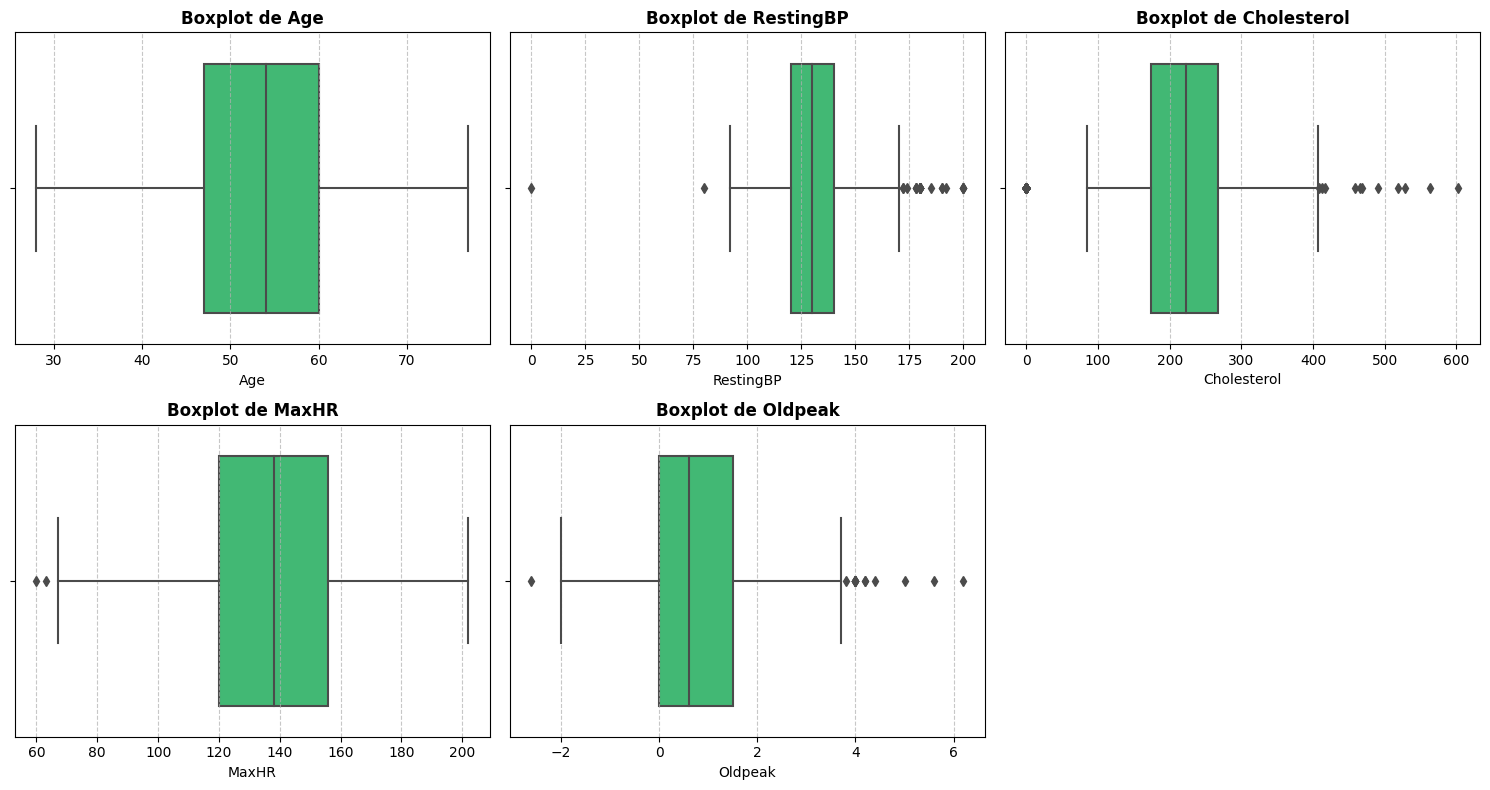

In [27]:
print("\nGenerando Boxplots...")
plot_boxplots(df, num_vars)

Los boxplots permiten caracterizar la distribución de cada variable continua e identificar valores atípicos. Age presenta una distribución simétrica con IQR entre aproximadamente 47 y 60 años y bigotes que se extienden de forma equilibrada hacia ambos extremos, sin outliers, siendo la variable más regular del conjunto. RestingBP muestra una caja compacta centrada alrededor de 130 mmHg con varios valores atípicos hacia la derecha superando los 175 mmHg, y un outlier aislado cercano a cero que probablemente corresponde a un error de registro.  

Cholesterol es la variable con mayor presencia de outliers, con numerosos puntos extremos por encima de 400 mg/dL y un valor atípico marcado cerca de cero que refuerza la sospecha de datos faltantes codificados como 0. MaxHR presenta una caja amplia centrada alrededor de 138 lpm con bigotes que se extienden simétricamente entre 60 y 202 lpm, y únicamente dos outliers inferiores, lo que sugiere una distribución relativamente bien comportada. Finalmente, Oldpeak tiene una caja comprimida con mediana cercana a cero e IQR entre 0 y 1.5, pero con varios outliers positivos que alcanzan hasta 6.2, confirmando una marcada asimetría hacia la derecha y que la depresión del segmento ST es nula o mínima en la mayoría de los pacientes.  

Ahora se verá la frecuencia de las variables "FastingBS" y "HeartDisease".  

#### FastingBS

In [ ]:
tabla= (
    df["FastingBS"]
    .value_counts()
    .reset_index()
    .rename(columns={'FastingBS': 'FastingBS', 'count': 'conteo'})
)
tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)

tabla

,FastingBS,conteo,Porcentaje
0,0,704,76.7
1,1,214,23.3


#### HeartDisease (variable de respuesta)

In [34]:
tabla = (
    df["HeartDisease"]
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'HeartDisease', 'HeartDisease': 'conteo'})
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)

tabla

,HeartDisease,conteo,Porcentaje
0,1,508,55.3
1,0,410,44.7


## Preprocesamiento y detección de Data Leakage  

Se implementaron y compararon dos flujos de modelado para la predicción de enfermedad cardíaca utilizando varios clasificadores optimizados con GridSearchCV. En el primer flujo se introdujo data leakage al incorporar una variable artificial derivada del target y al aplicar el preprocesamiento antes de la partición de los datos, lo que generó métricas infladas. En el segundo flujo, se corrigió este problema realizando la división train-test antes de cualquier transformación e integrando el preprocesamiento dentro de un Pipeline. Finalmente, se evaluaron los modelos mediante AUC y accuracy, evidenciando el impacto del data leakage en los resultados.

In [35]:
X = df.drop(columns="HeartDisease")
y = df["HeartDisease"]
 
# Columnas numéricas y categóricas
num_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
cat_cols = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
 
#Preprocesador compartido, primero se escalan las variables numéricas y luego a las variables categóricas se pasan a numéricas
preprocessor = ColumnTransformer([
    ("num", MinMaxScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])
 
#Este es mi pipeline 
def train_pipeline(X_train, y_train, model, param_grid):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", model)
    ])
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid
 
#Acá se valúa el modelo en cada iteración
def evaluar_grid(grid, X_test, y_test, nombre):
    y_pred  = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:, 1]
    return {
        "Modelo":         nombre,
        "AUC":            round(roc_auc_score(y_test, y_proba), 4),
        "Accuracy":       round(accuracy_score(y_test, y_pred), 4),
        "Mejor AUC CV":   round(grid.best_score_, 4),
        "Mejores params": grid.best_params_
    }
 
#Aquí se guardan los resultados para imprimir después

def mostrar_ranking(resultados, titulo):
    ranking = (
        pd.DataFrame(resultados)
        .sort_values("AUC", ascending=False)
        .reset_index(drop=True)
    )
    ranking.index += 1
    print(f"\n── {titulo} ──")
    print(ranking[["Modelo", "AUC", "Accuracy", "Mejor AUC CV"]].to_string())
    return ranking
 
#Aquí se definen los modelos a utilizar 
modelos = {
    "LogisticRegression": (
        LogisticRegression(max_iter=1000),
        {"clf__C": [0.01, 0.1, 1, 10],
         "clf__solver": ["lbfgs", "liblinear"]}
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=42),
        {"clf__n_estimators": [100, 200],
         "clf__max_depth": [None, 5, 10],
         "clf__min_samples_split": [2, 5]}
    ),
    "KNeighbors": (
        KNeighborsClassifier(),
        {"clf__n_neighbors": [3, 5, 7, 11],
         "clf__weights": ["uniform", "distance"]}
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(random_state=42),
        {"clf__n_estimators": [100, 200],
         "clf__learning_rate": [0.05, 0.1],
         "clf__max_depth": [3, 5]}
    )
}
 
#Flujo con Data Leakage

print("FLUJO CON DATA LEAKAGE")
 
# primer tipo de data leakage: selección de
np.random.seed(0)
X_leaky = X.copy()
X_leaky["leaky_feature"] = y + np.random.normal(0, 0.01, size=len(y))
 
# segundo tipo de data leakage, el preprocesador se ajusta con todo el dataset antes del split
preprocessor_leaky = ColumnTransformer([
    ("num", MinMaxScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])
X_leaky_arr = preprocessor_leaky.fit_transform(X_leaky)  # <- fuga aquí, la más comun que es estandarizar antes de dividir
 
# Split DESPUÉS del preprocesamiento (incorrecto). acá se produce la fuga
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leaky_arr, y, test_size=0.2, random_state=42, stratify=y
)
 
resultados_leakage = []
for nombre, (modelo, param_grid) in modelos.items():
 
    param_grid_leaky = {k.replace("clf__", ""): v for k, v in param_grid.items()}
    grid_l = GridSearchCV(modelo, param_grid_leaky, cv=5, scoring="roc_auc", n_jobs=-1)
    grid_l.fit(X_train_l, y_train_l)
 
    resultado = evaluar_grid(grid_l, X_test_l, y_test_l, nombre)
    resultados_leakage.append(resultado)
    print(f"  AUC: {resultado['AUC']:.4f} | Accuracy: {resultado['Accuracy']:.4f}")
 
ranking_leakage = mostrar_ranking(resultados_leakage, "Ranking comparativo — CON leakage")
 
#Flujo sin el Data Leakage 
print("FLUJO CORRECTO — SIN DATA LEAKAGE")
 
# Split ANTES de cualquier transformación (correcto)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
resultados = []
for nombre, (modelo, param_grid) in modelos.items():
    grid = train_pipeline(X_train, y_train, modelo, param_grid)
 
    resultado = evaluar_grid(grid, X_test, y_test, nombre)
    resultados.append(resultado)
    print(f"  AUC: {resultado['AUC']:.4f} | Accuracy: {resultado['Accuracy']:.4f}")
 
ranking_limpio = mostrar_ranking(resultados, "Ranking comparativo — SIN leakage")
 

FLUJO CON DATA LEAKAGE
  AUC: 0.9298 | Accuracy: 0.8913
  AUC: 0.9328 | Accuracy: 0.8967


c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\subprocess.py", line 1

  AUC: 0.9415 | Accuracy: 0.9022
  AUC: 0.9342 | Accuracy: 0.8913

── Ranking comparativo — CON leakage ──
               Modelo     AUC  Accuracy  Mejor AUC CV
1          KNeighbors  0.9415    0.9022        0.9128
2    GradientBoosting  0.9342    0.8913        0.9240
3        RandomForest  0.9328    0.8967        0.9294
4  LogisticRegression  0.9298    0.8913        0.9234
FLUJO CORRECTO — SIN DATA LEAKAGE
  AUC: 0.9297 | Accuracy: 0.8913
  AUC: 0.9327 | Accuracy: 0.8967
  AUC: 0.9382 | Accuracy: 0.9130
  AUC: 0.9342 | Accuracy: 0.8913

── Ranking comparativo — SIN leakage ──
               Modelo     AUC  Accuracy  Mejor AUC CV
1          KNeighbors  0.9382    0.9130        0.9149
2    GradientBoosting  0.9342    0.8913        0.9236
3        RandomForest  0.9327    0.8967        0.9294
4  LogisticRegression  0.9297    0.8913        0.9234


In [36]:
#Comparación final
 
print()
print("COMPARACIÓN: LEAKAGE vs. SIN LEAKAGE")

 
df_leakage = pd.DataFrame(resultados_leakage)[["Modelo", "AUC"]].rename(columns={"AUC": "AUC (leakage)"})
df_limpio  = pd.DataFrame(resultados)[["Modelo", "AUC"]].rename(columns={"AUC": "AUC (limpio)"})
 
comparacion = df_leakage.merge(df_limpio, on="Modelo")
comparacion["Diferencia"] = (comparacion["AUC (leakage)"] - comparacion["AUC (limpio)"]).round(4)
comparacion = comparacion.sort_values("AUC (limpio)", ascending=False).reset_index(drop=True)
comparacion.index += 1
 
print(comparacion.to_string())
print("\n-> Una diferencia positiva indica optimismo artificioso por el leakage.")


COMPARACIÓN: LEAKAGE vs. SIN LEAKAGE
               Modelo  AUC (leakage)  AUC (limpio)  Diferencia
1          KNeighbors         0.9415        0.9382      0.0033
2    GradientBoosting         0.9342        0.9342      0.0000
3        RandomForest         0.9328        0.9327      0.0001
4  LogisticRegression         0.9298        0.9297      0.0001

-> Una diferencia positiva indica optimismo artificioso por el leakage.


Los resultados muestran que el data leakage genera un leve optimismo en el desempeño de los modelos, evidenciado en valores de AUC ligeramente superiores en el flujo con fuga. Aunque las diferencias no son muy grandes, especialmente en modelos como Random Forest y Logistic Regression, el caso de KNN presenta la mayor variación, confirmando que algunos algoritmos son más sensibles a este problema. En general, el ranking de modelos se mantiene estable en ambos escenarios, lo que sugiere que el leakage no altera drásticamente la comparación relativa, pero sí introduce una sobreestimación del rendimiento. Por ello, se concluye que es fundamental evitar cualquier tipo de fuga de información para obtener métricas confiables y representativas del desempeño real del modelo.  